In [1]:
import matplotlib.pyplot as plt
import numpy as np
import common
from dataclasses import dataclass
from typing import List


In [2]:
%config InlineBackend.figure_format = 'retina'

In [4]:
@dataclass
class BarPlotData:
    y: List[float]
    name: str

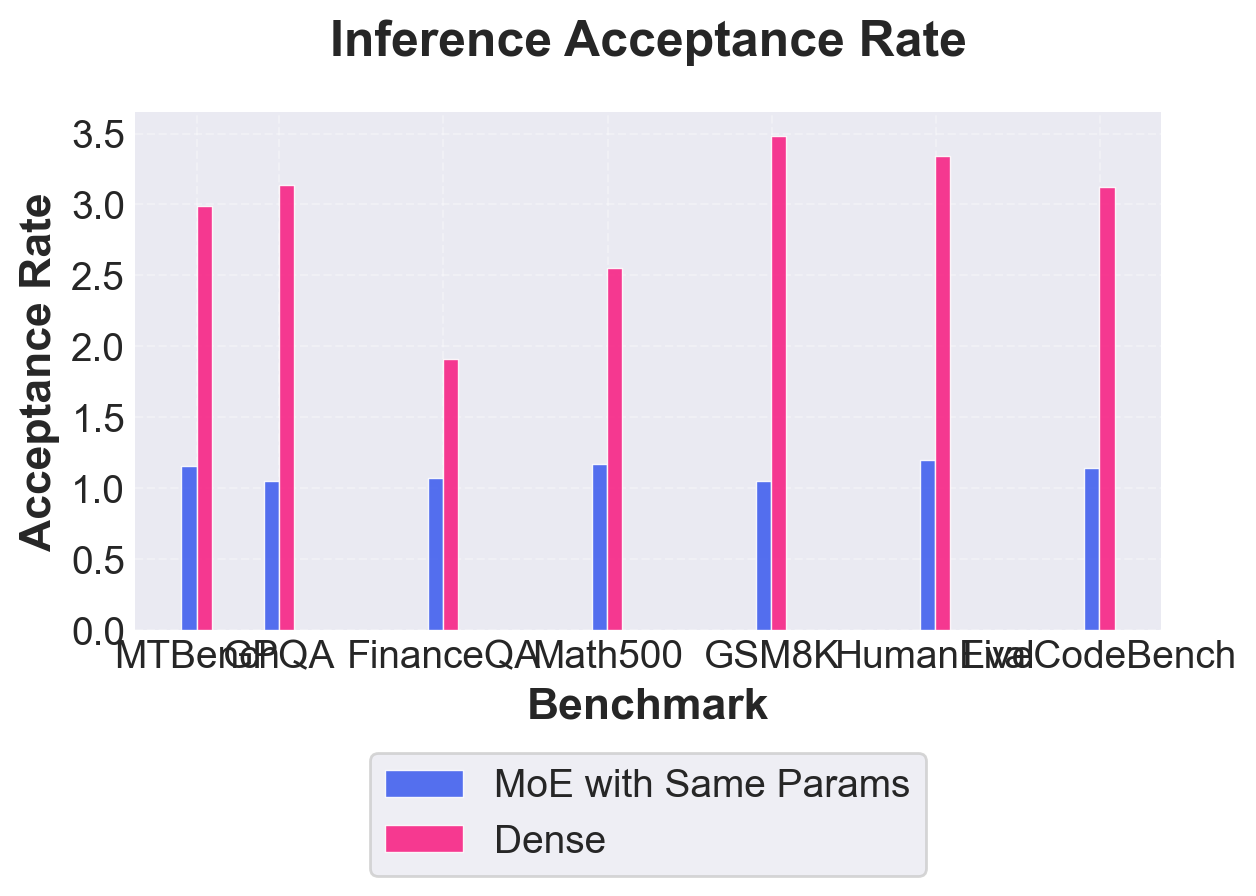

In [25]:
def generate_bar_plot(data_list: List[BarPlotData], x_label: str, y_label: str, title: str, x_ticks: List[str], show_legend: bool = True, show_grid: bool = True, num_legend_cols: int = 2):
    # compute the x point of each bar
    num_bars = len(data_list[0].y)
    num_data = len(data_list)
    
    # x = np.arange(num_bars)
    length_ratio = np.array([1.5, 1, 2, 2, 2, 2, 2])
    length_ratio = length_ratio / np.sum(length_ratio)
    length_ratio = np.cumsum(length_ratio)
    x = np.array([1000] * 7) * length_ratio
    bar_width = 15

    for idx, data in enumerate(data_list):
        cur_x = x + (idx - num_data / 2) * bar_width + bar_width // 2
        plt.bar(
            x=cur_x, 
            height=data.y, 
            color=common.COLORS[idx], 
            edgecolor='white', 
            linewidth=0.5, 
            alpha=0.9, 
            width=bar_width,
            label=data.name
            )

    plt.xlabel(x_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.ylabel(y_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.title(title, fontsize=common.TITLE_SIZE, fontweight='bold', pad=20)

    if x_ticks:
        plt.xticks(x, x_ticks, fontsize=common.X_TICK_FONT_SIZE)
        plt.yticks(fontsize=common.Y_TICK_FONT_SIZE)

    if show_legend:
        # put legend below the plot
        plt.legend(frameon=True, fontsize=common.LEGEND_FONT_SIZE, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=num_legend_cols)

    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()



# Generate sample data
labels = ['MTBench', 'GPQA', 'FinanceQA', 'Math500', 'GSM8K', 'HumanEval', 'LiveCodeBench']

dense = [2.99, 3.14, 1.91, 2.55, 3.48, 3.34, 3.12]
hetero_0_5 = [1.16, 1.05, 1.07, 1.17, 1.05, 1.2, 1.14]
two_experts = [1.61, 1.56, 1.34, 1.67, 1.59, 1.64, 1.46]
three_experts = [1.62, 1.69, 1.35, 1.77, 1.7, 1.67, 1.57]
four_experts = [1.63, 1.7, 1.36, 1.79, 1.72, 1.69, 1.59]

two_experts_with_shared = [1.52, 1.69, 1.5, 1.75, 1.61, 1.53, 1.52]
three_experts_with_shared = [1.52, 1.7, 1.46, 1.75, 1.61, 1.53, 1.52]
four_experts_with_shared = [1.53, 1.69, 1.47, 1.81, 1.67, 1.64, 1.54]

data_list = [
        BarPlotData(y=hetero_0_5, name='MoE with Same Params'),
        BarPlotData(y=dense, name='Dense'),
]


generate_bar_plot(
        data_list=data_list,
        x_label='Benchmark',
        y_label='Acceptance Rate',
        title='Inference Acceptance Rate',
        x_ticks=labels,
        show_legend=True,
        show_grid=True,
        num_legend_cols=1
)
plt.savefig('hetero-moe-acceptance.pdf', dpi=300)
plt.show()

[ 77. 177. 277. 377. 477. 577. 677.]
[1.61, 1.56, 1.34, 1.67, 1.59, 1.64, 1.46]
[ 92. 192. 292. 392. 492. 592. 692.]
[1.62, 1.69, 1.35, 1.77, 1.7, 1.67, 1.57]
[107. 207. 307. 407. 507. 607. 707.]
[1.63, 1.7, 1.36, 1.79, 1.72, 1.69, 1.59]
[122. 222. 322. 422. 522. 622. 722.]
[2.99, 3.14, 1.91, 2.55, 3.48, 3.34, 3.12]


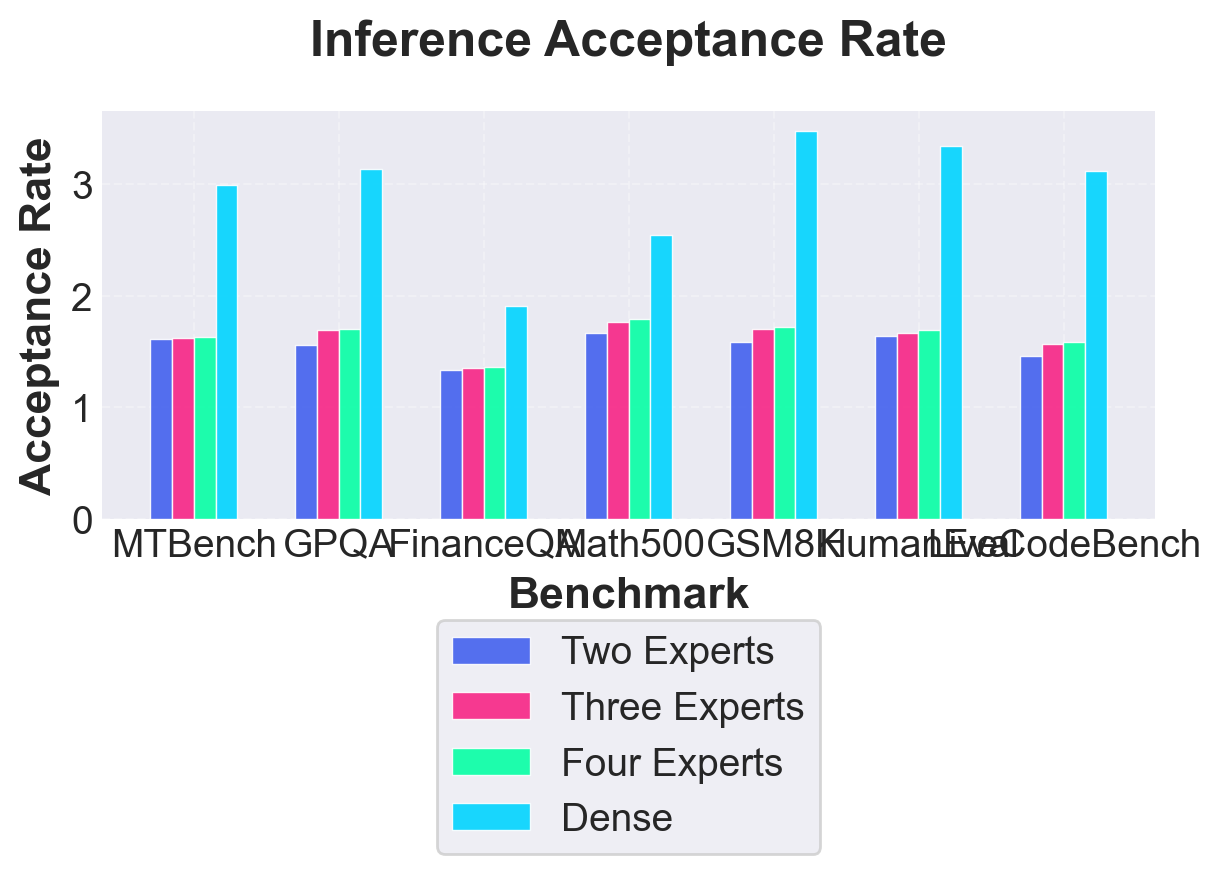

In [11]:
data_list = [
        BarPlotData(y=two_experts, name='Two Experts'),
        BarPlotData(y=three_experts, name='Three Experts'),
        BarPlotData(y=four_experts, name='Four Experts'),
        BarPlotData(y=dense, name='Dense'),
]


generate_bar_plot(
        data_list=data_list,
        x_label='Benchmark',
        y_label='Acceptance Rate',
        title='Inference Acceptance Rate',
        x_ticks=labels,
        show_legend=True,
        show_grid=True,
        num_legend_cols=1
)
plt.savefig('moe-acceptance.pdf', dpi=300)
plt.show()

[ 77. 177. 277. 377. 477. 577. 677.]
[1.52, 1.69, 1.5, 1.75, 1.61, 1.53, 1.52]
[ 92. 192. 292. 392. 492. 592. 692.]
[1.52, 1.7, 1.46, 1.75, 1.61, 1.53, 1.52]
[107. 207. 307. 407. 507. 607. 707.]
[1.53, 1.69, 1.47, 1.81, 1.67, 1.64, 1.54]
[122. 222. 322. 422. 522. 622. 722.]
[2.99, 3.14, 1.91, 2.55, 3.48, 3.34, 3.12]


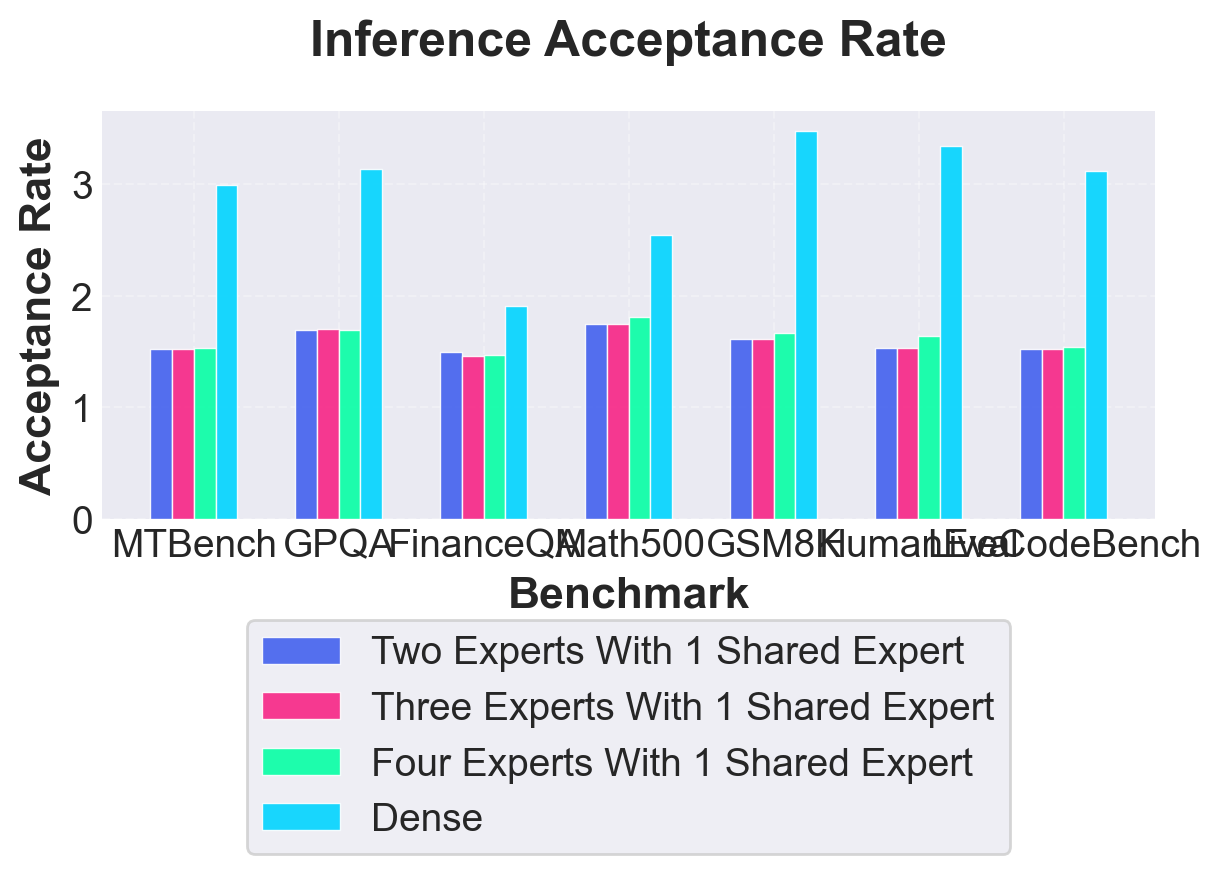

In [12]:
data_list = [
        BarPlotData(y=two_experts_with_shared, name='Two Experts With 1 Shared Expert'),
        BarPlotData(y=three_experts_with_shared, name='Three Experts With 1 Shared Expert'),
        BarPlotData(y=four_experts_with_shared, name='Four Experts With 1 Shared Expert'),
        BarPlotData(y=dense, name='Dense'),
]


generate_bar_plot(
        data_list=data_list,
        x_label='Benchmark',
        y_label='Acceptance Rate',
        title='Inference Acceptance Rate',
        x_ticks=labels,
        show_legend=True,
        show_grid=True,
        num_legend_cols=1
)
plt.savefig('moe-acceptance.pdf', dpi=300)
plt.show()